# Bracketing Local Minima

**CS164 - Optimization Methods**

This notebook organizes the main ideas and implementations from the bracketing PCW:

- visualizing example functions,
- locating local minima analytically,
- bracketing a local minimum without derivatives,
- reviewing the Intermediate Value Theorem (IVT),
- approximating derivatives with central differences,
- expanding an interval until it brackets a critical point,
- using bisection to approximate a local minimum.

The goal is not only to solve the exercises, but also to keep reusable numerical optimization code in a form that can be revisited later.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Illustrative examples

We begin with three functions:

1. $\cos(x)$ on $[0,6]$
2. $\cos(x)$ on $[0,12]$
3. $x\cos(x)$ on $[-3,12]$

Each function is plotted separately.

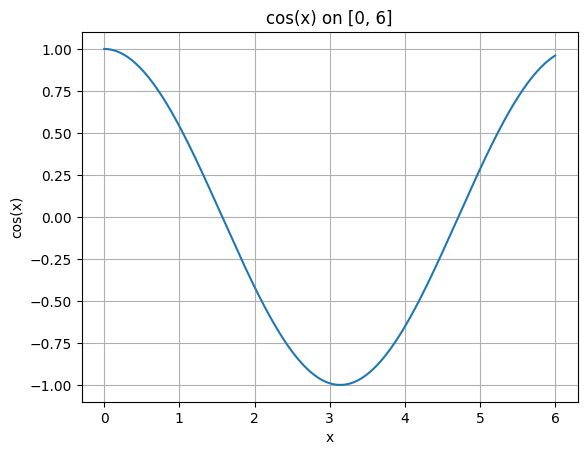

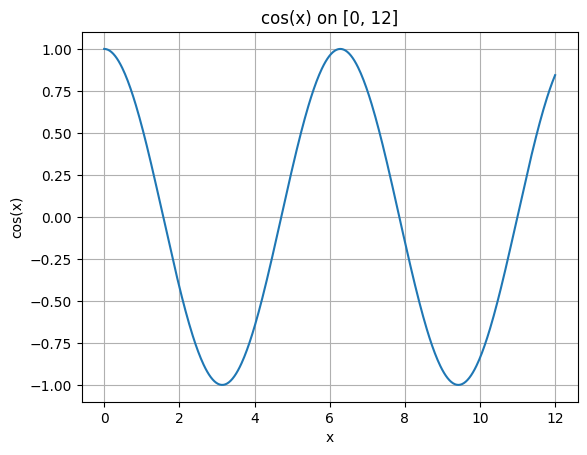

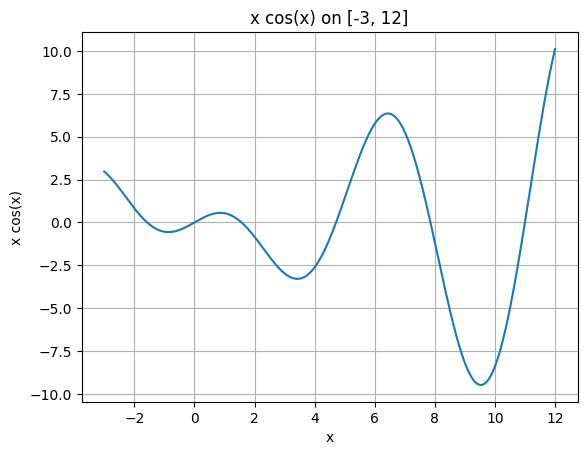

In [2]:
# cos(x) on [0, 6]
x1 = np.linspace(0, 6, 500)
plt.figure()
plt.plot(x1, np.cos(x1))
plt.xlabel("x")
plt.ylabel("cos(x)")
plt.title("cos(x) on [0, 6]")
plt.grid(True)
plt.show()

# cos(x) on [0, 12]
x2 = np.linspace(0, 12, 500)
plt.figure()
plt.plot(x2, np.cos(x2))
plt.xlabel("x")
plt.ylabel("cos(x)")
plt.title("cos(x) on [0, 12]")
plt.grid(True)
plt.show()

# x*cos(x) on [-3, 12]
x3 = np.linspace(-3, 12, 500)
plt.figure()
plt.plot(x3, x3 * np.cos(x3))
plt.xlabel("x")
plt.ylabel("x cos(x)")
plt.title("x cos(x) on [-3, 12]")
plt.grid(True)
plt.show()

### Local minima

For $\cos(x)$, local minima occur whenever

$$
x=(2k+1)\pi.
$$

Therefore:

- on $[0,6]$: $x\approx 3.14159265$
- on $[0,12]$: $x\approx 3.14159265$ and $x\approx 9.42477796$

For $f(x)=x\cos(x)$,

$$
f'(x)=\cos(x)-x\sin(x).
$$

Solving $f'(x)=0$ numerically and keeping the local minima in $[-3,12]$ gives

$$
x\approx -0.86033359,\quad 3.42561846,\quad 9.52933441.
$$

## 2. A simple bracketing algorithm

The first algorithm does **not** use derivatives. Its goal is only to find an interval that contains a local minimum.

### Natural-language pseudocode

1. Start at the initial point $x_0$.
2. Take one step of size $h$.
3. Compare the function value at the new point with the value at the starting point.
4. If the function increased, reverse the direction of $h$.
5. Continue moving in that direction while the function value decreases.
6. After each successful step, multiply the step size by the scaling factor $c$.
7. When the function value increases again, stop.
8. Return the two outer points around the lowest sampled point; these form a bracket containing a local minimum.
9. Stop after `max_iter` iterations if no bracket is found, preventing an infinite loop.

In [3]:
def bracket_minimum(f, x0, h, c, max_iter=100):
    """Find an interval that brackets a local minimum."""
    if h == 0:
        raise ValueError("h must be nonzero")
    if c <= 1:
        raise ValueError("c must be greater than 1")

    a = x0
    fa = f(a)

    b = a + h
    fb = f(b)

    # If the first move is uphill, reverse direction.
    if fb > fa:
        a, b = b, a
        fa, fb = fb, fa
        h = -h

    for _ in range(max_iter):
        x_next = b + h
        f_next = f(x_next)

        # We went downhill to b and then uphill at x_next.
        if f_next > fb:
            return min(a, x_next), max(a, x_next)

        a, fa = b, fb
        b, fb = x_next, f_next
        h *= c

    raise RuntimeError("Maximum number of iterations reached")


f1 = lambda x: np.cos(x)
f2 = lambda x: np.cos(x)
f3 = lambda x: x * np.cos(x)

print(bracket_minimum(f1, 0, 0.1, 1.5))
print(bracket_minimum(f2, 0, 0.1, 2))
print(bracket_minimum(f3, 0, 0.1, 2))

(2.1781250000000005, 5.0257812500000005)
(1.6, 6.4)
(-1.5, -0.30000000000000004)


### Performance of the simple bracketing algorithm

The algorithm successfully found intervals containing local minima for all three examples. The values of the initial step size $h$ and scaling factor $c$ affect the result: smaller scaling factors tend to give tighter brackets, while larger factors move faster but can produce much wider intervals.

For $x\cos(x)$ with $x_0=0$, the first positive step increases the function value, so the algorithm reverses direction and finds the local minimum on the negative side.

A limitation is that a function that keeps decreasing indefinitely may never produce the required increase. Very flat, plateau-like, or rapidly oscillating functions can also make the bracket less informative. This is why a maximum-iteration safeguard is useful.

## 3. Intermediate Value Theorem (IVT)

The IVT says that if a function is continuous on a closed interval $[a,b]$, then it takes every value between $f(a)$ and $f(b)$ somewhere on that interval.

### Real-world interpretation

Suppose a continuous function maps the energy supplied by a cooktop to the temperature of water in a pot. Let $a$ be the amount of energy supplied when the water is at $25^\circ$C and $b$ the amount supplied when it reaches $100^\circ$C.

If temperature changes continuously as energy is added, then for **every** temperature between $25^\circ$C and $100^\circ$C, there must be some amount of energy between $a$ and $b$ for which the water has exactly that temperature. For example, the water cannot continuously move from $25^\circ$C to $100^\circ$C without passing through $60^\circ$C.

**Correction noted while reviewing the PCW:** continuity is assumed on the entire closed interval $[a,b]$, including the endpoints. The endpoints themselves give the values $f(a)$ and $f(b)$.

## 4. Bisection method for a local minimum

For a differentiable function with continuous derivative, a local minimum can be located by finding an interval $[a,b]$ such that

$$
f'(a)<0 \qquad \text{and} \qquad f'(b)>0.
$$

By continuity of $f'$, there must be a point $c\in(a,b)$ where $f'(c)=0$.

For example, with $f(x)=\cos(x)$:

$$
f'(x)=-\sin(x).
$$

On $[3,4]$,

$$
f'(3)\approx -0.1411<0, \qquad f'(4)\approx 0.7568>0.
$$

Therefore a critical point lies in $(3,4)$. It is $x=\pi$, and because the derivative changes from negative to positive, it is a local minimum.

### Numerical implementation

Three pieces are needed:

1. `central_difference` approximates $f'(x)$ numerically.
2. `expand_interval` enlarges an initial interval until the derivative has the desired signs at the endpoints.
3. `bisection_minimum` repeatedly halves that interval until it reaches the requested precision.

In [4]:
def central_difference(f, x, h=1e-5):
    """Approximate f'(x) using the central difference method."""
    return (f(x + h) - f(x - h)) / (2 * h)


def expand_interval(f, a, b, h=1e-5, max_iter=100):
    """Expand [a,b] until f'(a) < 0 and f'(b) > 0."""
    for _ in range(max_iter):
        da = central_difference(f, a, h)
        db = central_difference(f, b, h)

        if da < 0 and db > 0:
            return a, b

        w = abs((b - a) / 2)
        a -= w
        b += w

    raise RuntimeError("Could not find a suitable interval.")


def bisection_minimum(f, a, b, epsilon=1e-8, h=1e-5, max_iter=1000):
    """Use bisection on f' to approximate a local minimum."""
    if central_difference(f, a, h) >= 0 or central_difference(f, b, h) <= 0:
        raise ValueError("Need f'(a) < 0 and f'(b) > 0.")

    for _ in range(max_iter):
        m = (a + b) / 2
        dm = central_difference(f, m, h)

        if abs(dm) < 1e-12:
            return m, m
        elif dm > 0:
            b = m
        else:
            a = m

        if abs(b - a) < epsilon:
            return a, b

    raise RuntimeError("Maximum number of iterations reached.")


tests = [
    ("cos(x) on [0, 6]", f1, 2.5, 2.75),
    ("cos(x) on [0, 12]", f2, 8.75, 9.0),
    ("x*cos(x) on [-3, 12]", f3, -1.2, -1.0),
]

for name, f, a, b in tests:
    a, b = expand_interval(f, a, b)
    left, right = bisection_minimum(f, a, b)

    print(name)
    print("Bracket:", (left, right))
    print("Minimum estimate:", (left + right) / 2)
    print()

cos(x) on [0, 6]
Bracket: (3.141592651605606, 3.1415926590561867)
Minimum estimate: 3.1415926553308964

cos(x) on [0, 12]
Bracket: (9.424777954816818, 9.424777962267399)
Minimum estimate: 9.424777958542109

x*cos(x) on [-3, 12]
Bracket: (-0.8603335916996003, -0.8603335857391359)
Minimum estimate: -0.8603335887193682



## 5. Performance report

The bisection-based algorithm performed well on all three examples. Starting from small initial intervals, the expansion method found intervals where the derivative changed from negative to positive. Bisection then narrowed those intervals to a width below $10^{-8}$.

The estimates are very close to the analytically or numerically known minima. One important limitation is that the cosine examples have multiple local minima, so the solution found depends on the initial interval. A different starting interval can lead to a different local minimum. The central-difference approximation also introduces a small amount of numerical error, although it was not significant for these examples.

### Main takeaway

Bracketing separates optimization into two useful stages:

1. **Find an interval that is known to contain a local minimum.**
2. **Systematically shrink that interval.**

This is a recurring idea in numerical optimization and leads naturally to more advanced one-dimensional methods such as Fibonacci search, golden-section search, quadratic interpolation, secant-based methods, Brent-Dekker methods, and global methods such as Shubert-Piyavskii.